<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
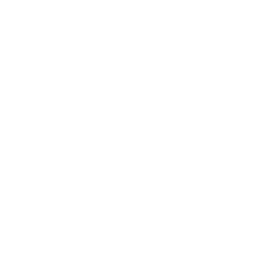
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">공정 최적화를 위한 분할구 설계</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 제조 / 품질공학 &nbsp;|&nbsp; 2026년 3월</p>
</div>
</div>
</div>

## 요약

이 노트북은 사출성형 공정에 대한 분할구(split-plot) 실험을 분석한다. 전체구(whole-plot) 요인은 바꾸기 어려운 **기계**(machine, 4수준: MACH_A~MACH_D)이고, 부분구(sub-plot) 요인은 바꾸기 쉬운 **속도 설정**(speed setting, 5수준: 60, 80, 100, 120, 140 RPM)이다. 각 기계x속도 조합마다 5회 반복측정을 수행하여 100개의 불량률 관측치를 얻는다.

`PROC MIXED`는 **기계를 무작위효과**(전체구 오차층)로, **속도를 고정효과**(부분구 요인)로 처리하여 제한된 무작위화 구조를 올바르게 적합한다. 이 분석은 두 분산성분을 추정하고, 속도 효과를 검정하며, 불량률을 최소화하는 운전 속도를 찾기 위해 속도 최소제곱평균의 Tukey 보정 쌍별 비교를 산출한다.

## 데이터 출처

| 출처 | 설명 | 레코드 수 |
|--------|-------------|--------|
| WORK.MOLDING_EXPERIMENT | 분할구 실험 데이터: 기계 4종 x 속도 5수준 x 반복 5회 | 100 |

---

In [1]:
/* --------------------------------------------------------
   합성 분할구 사출성형 데이터 생성
   기계 4대(전체구) x 속도 5수준(부분구) x 반복 5회
   각 전체구에 추가 반복
   -------------------------------------------------------- */
데이터 work.molding_experiment;
    호출 streaminit(42);
    배열 machine_names[4] $12 _temporary_ ('MACH_A' 'MACH_B' 'MACH_C' 'MACH_D');
    배열 speed_settings[5] _temporary_ (60 80 100 120 140);
    /* 기계 참효과(무작위) */
    배열 mach_eff[4] _temporary_ (2.1 -1.5 0.8 -1.4);
    /* 속도 참효과(고정, 최적점이 약 100 부근인 2차식) */
    배열 speed_eff[5] _temporary_ (3.2 1.0 -0.5 0.8 4.5);
    obs_id = 0;
    반복 whole_plot = 1 까지 5;
        반복 m = 1 까지 4;
            machine = machine_names[m];
            machine_id = cat('WP_', PUT(whole_plot, z2.), '_', machine);
            /* 전체구 반복 효과 */
            wp_noise = rand('normal', 0, 1.5);
            반복 s = 1 까지 5;
                speed = speed_settings[s];
                speed_label = cat(PUT(speed, 3.), 'RPM');
                /* 각 전체구 내 부분구 반복 */
                반복 rep = 1 까지 5;
                    obs_id + 1;
                    /* 불량률: 절편 + 기계 + 속도 + 상호작용 + 잡음 */
                    defect_rate = round(
                        8.0 + mach_eff[m] + speed_eff[s] +
                        wp_noise +
                        0.3 * (m - 2) * (s - 3) +
                        rand('normal', 0, 1.2),
                    0.01);
                    만약 defect_rate < 0 이면 defect_rate = 0.01;
                    /* 이차 반응변수: 인장강도 */
                    tensile_strength = round(
                        45 - 0.5 * defect_rate +
                        rand('normal', 0, 2),
                    0.1);
                    출력;
                종료;
            종료;
        종료;
    종료;
    제거 m s mach_eff1-mach_eff4 speed_eff1-speed_eff5 wp_noise;
실행;


NOTE: DATA work.molding_experiment

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.molding_experiment (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.05 seconds
  cpu   0.05 seconds


---

In [2]:
/* --------------------------------------------------------
   기준선: 기계 및 속도별 불량률 요약
   -------------------------------------------------------- */
처리 MEANS 데이터=work.molding_experiment n mean std;
    분류 machine speed_label;
    변수 defect_rate tensile_strength;
    라벨 machine="기계" speed_label="속도설정" defect_rate="불량률" tensile_strength="인장강도";
    제목 '기계 및 속도별 불량률과 인장강도';
실행;

                                                   기계 및 속도별 불량률과 인장강도                                                   

                                                  The MEANS Procedure

                                       Analysis Variable : defect_rate 불량률

        기계        속도설정                  N Obs           Mean        Std Dev
        -------------------------------------------------------------------
        MACH_A     60RPM                    5     12.9460000      1.0100149
        MACH_A     80RPM                    5     10.0160000      0.6740401
        MACH_A    100RPM                    5      7.5980000      0.9787083
        MACH_A    120RPM                    5     10.2660000      0.9490416
        MACH_A    140RPM                    5     13.7120000      0.9359594
        MACH_B     60RPM                    5     11.7420000      0.9476656
        MACH_B     80RPM                    5      8.5580000      1.0129018
        MACH_B    100RPM                    5  


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                                   기계 및 속도별 불량률과 인장강도                                                   




NOTE: PROC MEANS
NOTE: Output dataset work.cell_means has 30 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.cell_means

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


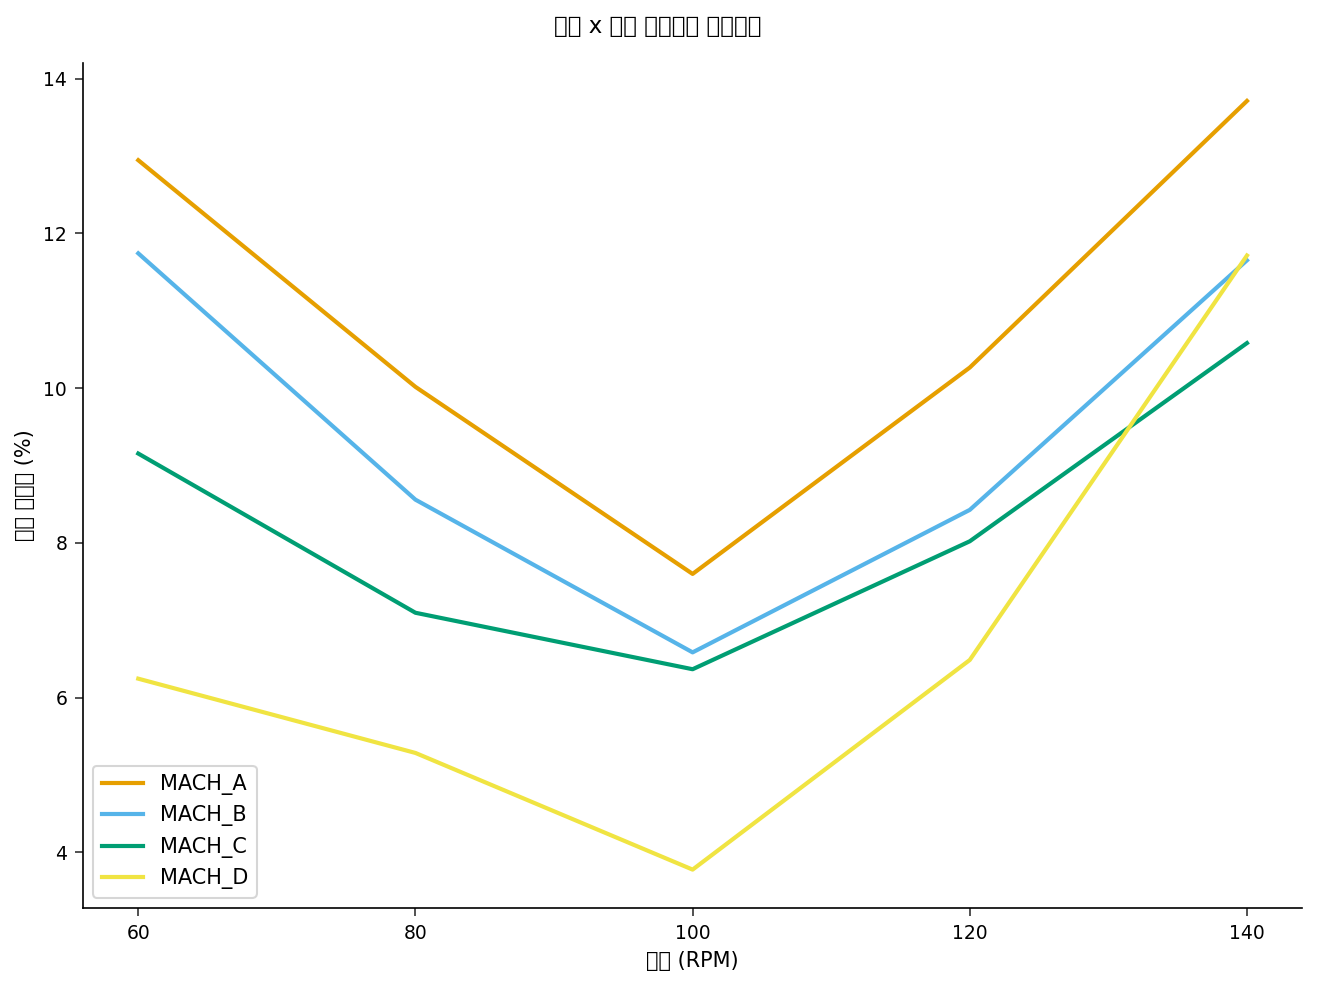

In [3]:
/* --------------------------------------------------------
   상호작용 플롯: 속도와 기계별 평균 불량률
   -------------------------------------------------------- */
처리 MEANS 데이터=work.molding_experiment NOPRINT;
    분류 machine speed;
    변수 defect_rate;
    출력 out=work.cell_means mean=mean_defect;
실행;

처리 SGPLOT 데이터=work.cell_means(where=(_type_=3));
    SERIES x=speed y=mean_defect / GROUP=machine
        LINEATTRS=(thickness=2) MARKERS;
    XAXIS label='속도 (RPM)' VALUES=(60 80 100 120 140);
    YAXIS label='평균 불량률 (%)';
    제목 '기계 x 속도 상호작용 프로파일';
실행;

---

                                                   기계 및 속도별 불량률과 인장강도                                                   

          The Mixed Procedure           
           Model Information            

Item                               Value
-------------------------  -------------
Dependent Variable                   불량률
Estimation Method                   REML
Degrees of Freedom Method  Kenward-Roger
Number of Observations               100

Covariance Parameter Estimates

Cov Parm   Subject   Estimate
---------  --------  --------
Intercept  machine     3.1033
Residual               1.6566

          Type III Tests of Fixed Effects           

Effect          Num DF    Den DF   F Value    Pr > F
------------  --------  --------  --------  --------
속도설정                 4      92.0     60.26    <.0001

         Fit Statistics          

Statistic                   Value
-----------------------  --------
-2 Res Log Likelihood    347.3514
AIC (Smaller is Better)  361.3513
BIC (Small


NOTE: PROC MIXED data=work.molding_experiment

NOTE: PROC MIXED: using R wrapper (mixed_renderer.R).
NOTE: PROC MIXED results written to: ./ods_output/mixed_results.spec.json
NOTE: lmer formula: defect_rate ~ speed_label + (1 | machine)
NOTE: Warning message:
NOTE: In readLines(con = "stdin") : incomplete final line found on 'stdin'
NOTE: ODS plot written: mixed_residuals_vs_predicted.spec.json
NOTE: ODS plot written: mixed_residual_histogram_panel.spec.json
NOTE: ODS plot written: mixed_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: mixed_qq_plot.spec.json
NOTE: ODS plot written: mixed_diagnostics.spec.json
NOTE: PROC MIXED ODS Graphics generated.
NOTE: ODS OUTPUT: SolutionF written to 'split_fixed'.
NOTE: ODS OUTPUT: CovParms written to 'split_covparms'.
NOTE: ODS OUTPUT: LSMeans written to 'speed_lsmeans'.
NOTE: ODS OUTPUT: FitStatistics written to 'split_fit'.
NOTE: ODS OUTPUT: Diffs written to 'speed_diffs'.


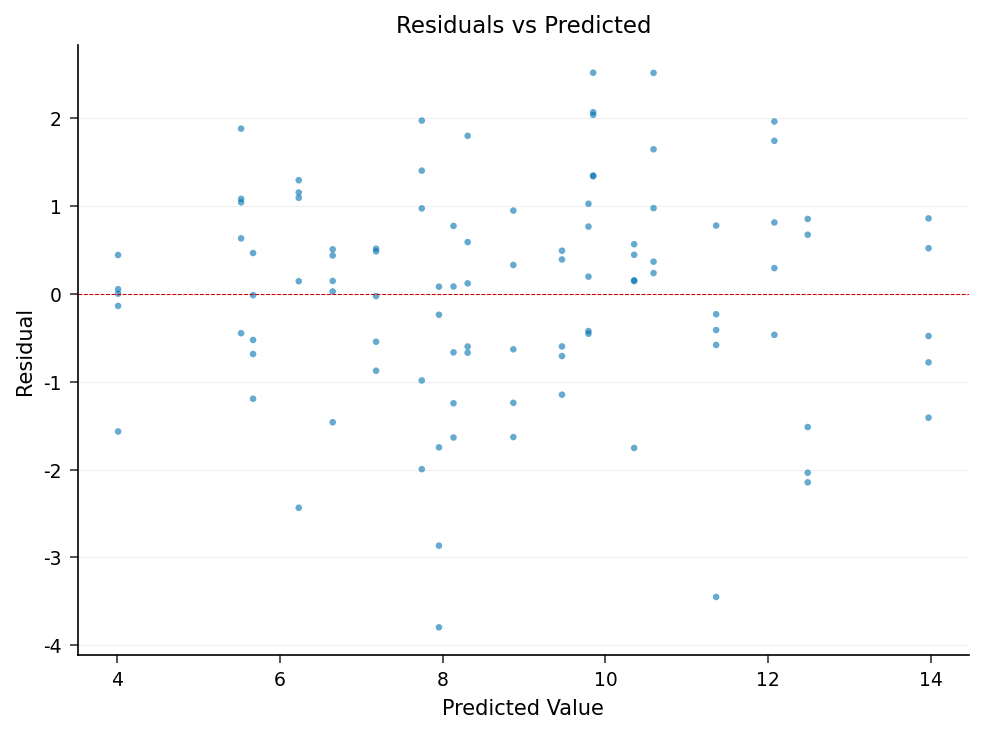

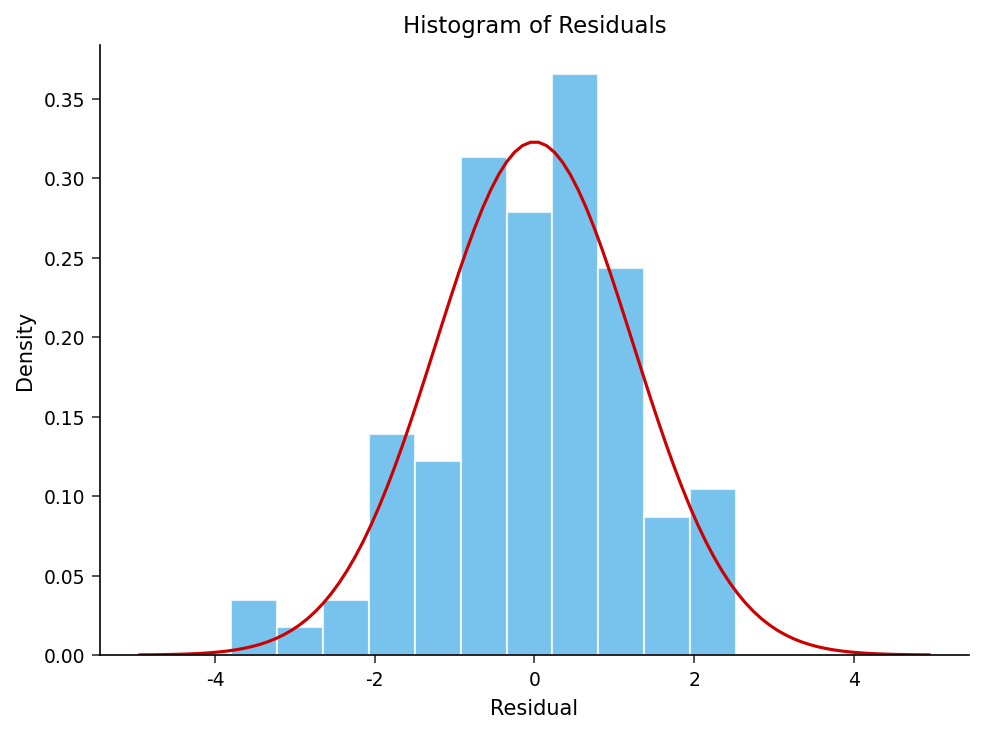

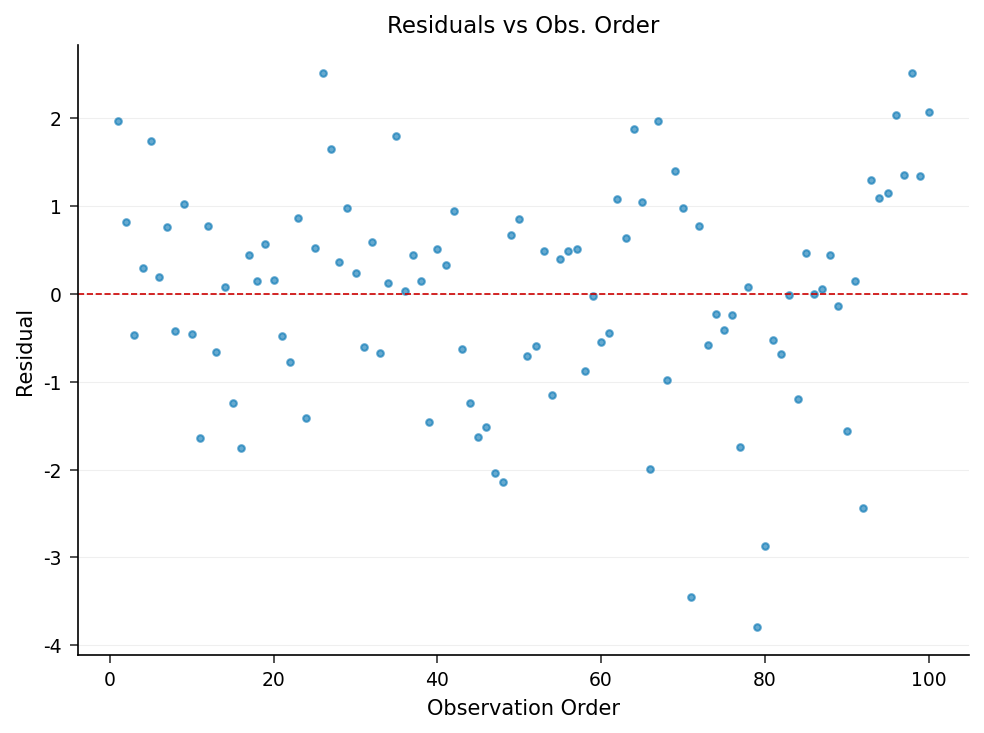

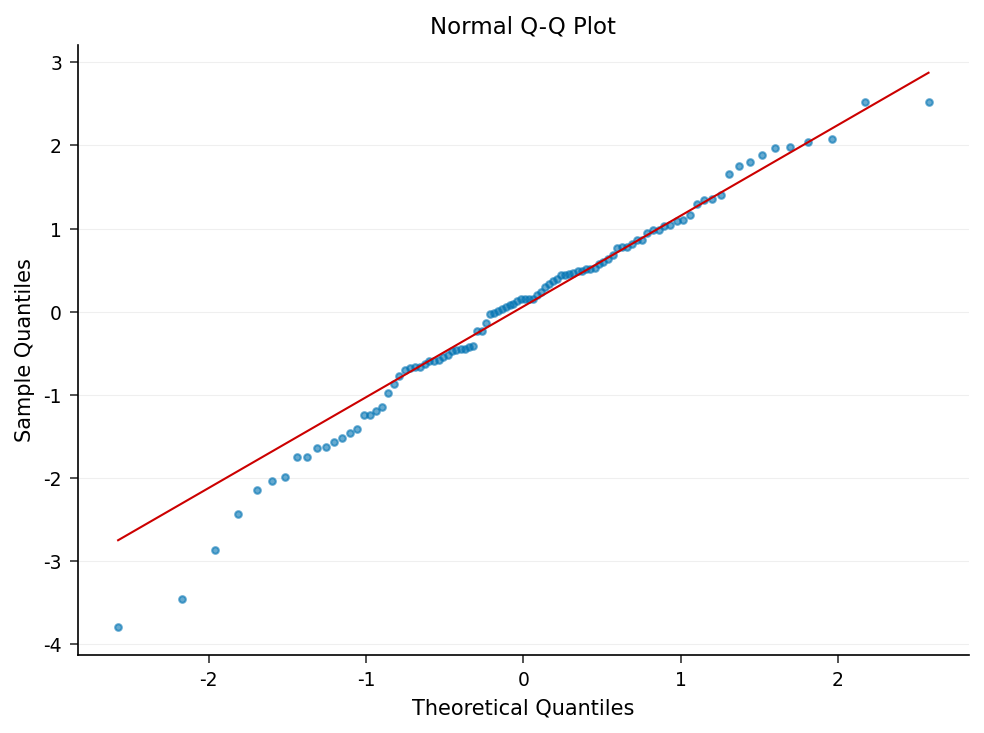

In [4]:
/* --------------------------------------------------------
   분할구 혼합모형 분석
   기계는 무작위(전체구 오차)
   속도는 고정(부분구 요인)
   -------------------------------------------------------- */
처리 MIXED 데이터=work.molding_experiment METHOD=reml;
    분류 machine speed_label;
    모형 defect_rate = speed_label / SOLUTION ddfm=kr;
    RANDOM machine;
    LSMEANS speed_label / ADJUST=TUKEY DIFF cl;
    ODS OUTPUT LSMEANS=work.speed_lsmeans
              diffs=work.speed_diffs
              covparms=work.split_covparms
              fitstatistics=work.split_fit
              solutionf=work.split_fixed;
    라벨 machine="기계" speed_label="속도설정" defect_rate="불량률";
    제목 '분할구 분석: 속도가 불량률에 미치는 영향';
실행;

In [5]:
/* --------------------------------------------------------
   최적 속도 설정 확인
   -------------------------------------------------------- */
처리 SORT 데이터=work.speed_lsmeans;
    기준 estimate;
실행;

데이터 work.optimal_speed;
    설정 work.speed_lsmeans(obs=1);
    유지 speed_label estimate stderr LOWER UPPER;
    라벨 speed_label = '최적 속도'
          estimate = 'LS평균 불량률'
          LOWER = '95% 신뢰구간 하한'
          UPPER = '95% 신뢰구간 상한';
실행;

처리 PRINT 데이터=work.optimal_speed noobs 라벨;
    제목 '불량률 최소화를 위한 권장 운전 속도';
실행;

                                                  불량률 최소화를 위한 권장 운전 속도                                                  

        최적 속도            LS평균 불량률  StdErr              95% 신뢰구간 하한              95% 신뢰구간 상한
            .               6.081  0.9266                   3.3645                   8.7975




NOTE: PROC SORT data=work.speed_lsmeans

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from work.speed_lsmeans.
NOTE: Wrote work.speed_lsmeans (5 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.optimal_speed


NOTE: Read 1 rows from work.speed_lsmeans.
NOTE: Wrote work.optimal_speed (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.optimal_speed

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


In [6]:
/* --------------------------------------------------------
   분산성분 분해
   -------------------------------------------------------- */
처리 PRINT 데이터=work.split_covparms noobs 라벨;
    라벨 covparm="공분산 항" estimate="추정값";
    제목 '분산성분: 기계 대 잔차';
실행;

                                                     분산성분: 기계 대 잔차                                                      

        공분산 항        추정값
Intercept         3.1033
Residual          1.6566




NOTE: PROC PRINT data=work.split_covparms

NOTE: PROC PRINT completed: 2 observations printed, 2 variables


---

### 해석

분할구 모형은 불량률의 변동을 두 층으로 분해한다. **기계(전체구) 분산성분은 3.10**이고 **잔차(부분구) 분산은 1.66**이므로, 기계 간 차이가 전체 분산의 약 **65%**를 차지한다(3.10 / (3.10 + 1.66)). 이처럼 기계 간 비중이 큰 것은 기계가 실질적인 공정 변동 원인임을 확인해주며, 완전 무작위화 분석이 아니라 분할구 설계가 올바른 분석 틀임을 뒷받침한다.

고정효과인 속도의 Type III 검정은 매우 유의하다: **F(4, 92) = 60.26, p < .0001**로, RPM 설정이 불량률에 강하게 영향을 미친다. 최소제곱평균은 중간 속도에서 최솟값을 갖는 뚜렷한 2차 반응을 그린다:

| 속도 | LS평균 불량률(%) | 95% CI |
|-------|------------------------|--------|
| **100 RPM** | **6.08** | 3.36 - 8.80 |
| 80 RPM | 7.74 | 5.02 - 10.46 |
| 120 RPM | 8.30 | 5.58 - 11.02 |
| 60 RPM | 10.02 | 7.31 - 12.74 |
| 140 RPM | 11.92 | 9.20 - 14.63 |

Tukey 보정 쌍별 비교에 따르면 **100 RPM은 다른 모든 설정보다 유의하게 낮다**(80, 120, 60, 140 RPM 대비 보정 p <= 0.0009). 80 RPM과 120 RPM은 중간 수준에 있으며 서로 **차이가 없다**(차이 0.56, 보정 p = 0.6430). 반면 60 RPM과 140 RPM은 가장 높은 불량률을 낸다.

**엔지니어링 권고:** 네 기계 모두 **100 RPM**으로 표준화하여 생산하라. 이 지점에서 모형은 가장 낮은 불량률(6.08%)을 추정한다. 기계 분산성분(3.10)이 변동의 지배적 원인이므로, 후속 작업은 기계별 캘리브레이션을 목표로 삼아야 한다 - 상호작용 프로파일을 보면 MACH_D가 일관되게 가장 낮고 MACH_A가 가장 높으므로 - 선택된 100 RPM 설정점에서 기계 간 격차를 좁혀야 한다.

---

In [7]:
/* --------------------------------------------------------
   엔지니어링 팀을 위한 속도 최적화 결과 내보내기
   -------------------------------------------------------- */
처리 EXPORT 데이터=work.speed_lsmeans
    OUTFILE='speed_optimization_lsmeans.csv'
    DBMS=csv REPLACE;
실행;

처리 EXPORT 데이터=work.split_covparms
    OUTFILE='variance_components.csv'
    DBMS=csv REPLACE;
실행;


NOTE: PROC EXPORT data=work.speed_lsmeans outfile=speed_optimization_lsmeans.csv

NOTE: Exported 5 rows to speed_optimization_lsmeans.csv.
NOTE: PROC EXPORT data=work.split_covparms outfile=variance_components.csv

NOTE: Exported 2 rows to variance_components.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 기밀
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
<a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a> 제공
</div>
</div>